Importing the dataset

In [1]:
import pandas as pd
df=pd.read_csv("data.csv")
df


,ID,air_time1,disp_index1,gmrt_in_air1,gmrt_on_paper1,max_x_extension1,max_y_extension1,mean_acc_in_air1,mean_acc_on_paper1,mean_gmrt1,...,mean_jerk_in_air25,mean_jerk_on_paper25,mean_speed_in_air25,mean_speed_on_paper25,num_of_pendown25,paper_time25,pressure_mean25,pressure_var25,total_time25,class
0,id_1,5160,0.000013,120.804174,86.853334,957,6601,0.361800,0.217459,103.828754,...,0.141434,0.024471,5.596487,3.184589,71,40120,1749.278166,296102.7676,144605,P
1,id_2,51980,0.000016,115.318238,83.448681,1694,6998,0.272513,0.144880,99.383459,...,0.049663,0.018368,1.665973,0.950249,129,126700,1504.768272,278744.2850,298640,P
2,id_3,2600,0.000010,229.933997,172.761858,2333,5802,0.387020,0.181342,201.347928,...,0.178194,0.017174,4.000781,2.392521,74,45480,1431.443492,144411.7055,79025,P
3,id_4,2130,0.000010,369.403342,183.193104,1756,8159,0.556879,0.164502,276.298223,...,0.113905,0.019860,4.206746,1.613522,123,67945,1465.843329,230184.7154,181220,P
4,id_5,2310,0.000007,257.997131,111.275889,987,4732,0.266077,0.145104,184.636510,...,0.121782,0.020872,3.319036,1.680629,92,37285,1841.702561,158290.0255,72575,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,id_170,2930,0.000010,241.736477,176.115957,1839,6439,0.253347,0.174663,208.926217,...,0.119152,0.020909,4.508709,2.233198,96,44545,1798.923336,247448.3108,80335,H
170,id_171,2140,0.000009,274.728964,234.495802,2053,8487,0.225537,0.174920,254.612383,...,0.174495,0.017640,4.685573,2.806888,84,37560,1725.619941,160664.6464,345835,H
171,id_172,3830,0.000008,151.536989,171.104693,1287,7352,0.165480,0.161058,161.320841,...,0.114472,0.017194,3.493815,2.510601,88,51675,1915.573488,128727.1241,83445,H
172,id_173,1760,0.000008,289.518195,196.411138,1674,6946,0.518937,0.202613,242.964666,...,0.114472,0.017194,3.493815,2.510601,88,51675,1915.573488,128727.1241,83445,H


Creating X(features) and y(label)

In [2]:
import numpy as np
features_column=df.columns[1:-1] #except id and label
label_column=df.columns[-1] #only label
X=df[features_column].values #returns only the values of the column
y_text=df[label_column].values
y=(y_text=='P').astype(int) #1-P and 0-H

Preprocessing

In [3]:
from sklearn.preprocessing import StandardScaler #scaling
from sklearn.decomposition import PCA #reduce the dimension
from sklearn.pipeline import Pipeline #chain steps
preprocess=Pipeline([('scaler1',StandardScaler()),('pca',PCA(n_components=24,random_state=42)),('scaler2',StandardScaler())])
X_processing=preprocess.fit_transform(X) #fit and transform

6-q circuit

In [4]:
from qiskit import QuantumCircuit #to build circuits
from qiskit.circuit import ParameterVector
import numpy as np
"""
    6‑qubit feature map with 24 parameters, bandwidth‑scaled.

    Structure (inspired by Fig. 3 in the paper):
    - 2 encoding layers of RY + RZ (single‑qubit rotations)
    - 2 entangling layers: CZ ring then CX ring
    Total parameters: 6 qubits * 2 rotations/layer * 2 encoding layers = 24.
    """
def make_6q_pqc(bandwidth): #x is preprocessed, bandwidth scales all rotation angles
    x=ParameterVector("x",24)
    theta=[bandwidth * p for p in x] #scale the features
    qc=QuantumCircuit(6)#create a 6-qubit circuit
    # 4 encoding blocks. each block uses 6 angles
    #RY->CZ 4 times
    idx=0
    #encoding layer 1: RX and RY
    for q in range(6):
        qc.rx(theta[idx],q) #first 6 params
        idx+=1
    for q in range(6):
        qc.ry(theta[idx],q)
        idx+=1
    #entangling layer 1:CZ ring
    for q in range(5):
        qc.cz(q,q+1)
    qc.cz(5,0) #close the ring
    #encoding layer 2 : RX and RY
    for q in range(6):
        qc.rx(theta[idx],q) #next 6 params
        idx+=1
    for q in range(6):
        qc.ry(theta[idx],q)
        idx+=1
    #entangling layer 2:CX ring
    for q in range(5):
        qc.cx(q,q+1)
    qc.cx(5,0)
    return qc


6-q kernel

In [5]:
from qiskit.primitives import StatevectorSampler
from qiskit import QuantumCircuit
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.model_selection import ShuffleSplit,train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np
pqc=QuantumCircuit()
#let fidelity kernel use the internal default statevector simulator (noiseless simulator)
def make_6q_kernel(bandwidth): #FidelityQuantumKernel using 6q pqc and aer based estimator
    pqc=make_6q_pqc(bandwidth)
    qkernel=FidelityQuantumKernel(feature_map=pqc)
    return qkernel


Calculating the condition number across various bandwidth for 6q circuit

In [6]:
import numpy as np
import matplotlib.pyplot as plt
bandwidth_grid=np.linspace(0.1,2.0,20)
cond_6q=[]
for bw in bandwidth_grid:
  qk6=make_6q_kernel(bw)
  K6=qk6.evaluate(X_processing)
  cond_6q.append(np.linalg.cond(K6))

8q circuit


In [7]:
from qiskit import QuantumCircuit #to build circuits
from qiskit.circuit import ParameterVector
import numpy as np
"""
8-qubit ansatz with 24 parameters, bandwidth-scaled.

Structure: 3 encoding layers of RX→RY→RX alternating with 2 entangling layers of CZ→CX.
Total parameters: 24 (scaled to 8 qubits from 6-qubit's 24 params).
"""
def make_8q_pqc(bandwidth): #x is preprocessed, bandwidth scales all rotation angles
    x=ParameterVector("x",24)
    theta=bandwidth*x #scale the features
    qc=QuantumCircuit(8)#create a 8-qubit circuit
    idx=0
    #encoding layer 1:RX (8 params)
    for q in range(8):
        qc.rx(theta[idx],q)
        idx+=1
    #encoding layer 2:RY(8 params)
    for q in range(8):
        qc.ry(theta[idx],q)
        idx+=1
    #entangling layer 1:CZ ring
    for q in range(7):
        qc.cz(q,q+1)
    qc.cz(7,0) #close the ring
    #encoding layer 3 : RX (8 params)
    for q in range(8):
        qc.rx(theta[idx],q)
        idx+=1
    #entangling layer 2:CX ring
    for q in range(7):
        qc.cx(q,q+1)
    qc.cx(7,0)
    return qc


8q kernel

In [8]:
from qiskit.primitives import StatevectorSampler
from qiskit import QuantumCircuit
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.model_selection import ShuffleSplit,train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np
pqc=QuantumCircuit()
#let fidelity kernel use the internal default statevector simulator (noiseless simulator)
def make_8q_kernel(bandwidth): #FidelityQuantumKernel using 8q pqc and aer based estimator
    pqc=make_8q_pqc(bandwidth)
    qkernel=FidelityQuantumKernel(feature_map=pqc)
    return qkernel


Calculating the condition number across various bandwidth for 8q circuit

In [9]:
import numpy as np
import matplotlib.pyplot as plt
bandwidth_grid=np.linspace(0.1,2.0,20)
cond_8q=[]
for bw in bandwidth_grid:
  qk8=make_8q_kernel(bw)
  K8=qk8.evaluate(X_processing)
  cond_8q.append(np.linalg.cond(K8))

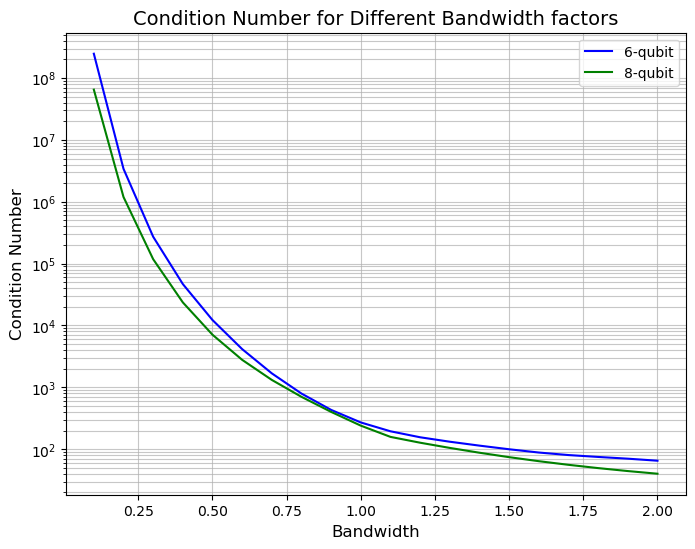

In [11]:
plt.figure(figsize=(8, 6))
plt.semilogy(bandwidth_grid, cond_6q, 'b', label='6-qubit')
plt.semilogy(bandwidth_grid, cond_8q, 'g', label='8-qubit')
plt.title('Condition Number for Different Bandwidth factors', fontsize=14)
plt.xlabel('Bandwidth', fontsize=12)
plt.ylabel('Condition Number', fontsize=12)
plt.grid(True, which="both", linestyle='-', alpha=0.7)
plt.legend()
plt.show()

12-qubit circuit

In [10]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

def make_12q_pqc(bandwidth):
    """
    12-qubit feature map using 24 unique parameters (reused for both encoding layers).
    Structure:
      - encoding layer 1: RX(x[0..11]) then RY(x[12..23])
      - entangling layer 1: CZ ring
      - encoding layer 2: reuse RX(x[0..11]) then RY(x[12..23])
      - entangling layer 2: CX ring
    """
    x = ParameterVector("x", 24)# 24 unique parameters
    theta=[bandwidth * p for p in x] #scale the features
    qc = QuantumCircuit(12)
    #encoding layer 1 (RX then RY)
    for q in range(12):
        qc.rx(theta[q], q)
    for q in range(12):
        qc.ry(theta[12 + q], q)
    #entangling layer 1: CZ ring
    for q in range(11):
        qc.cz(q, q + 1)
    qc.cz(11, 0)
    #encoding layer 2 (reuse same 24 parameters)
    # reset to same parameters (so no index-out-of-range)
    for q in range(12):
        qc.rx(theta[q], q)
    for q in range(12):
        qc.ry(theta[12 + q], q)
    #entangling layer 2: CX ring
    for q in range(11):
        qc.cx(q, q + 1)
    qc.cx(11, 0)
    return qc


12q kernel

In [11]:
from qiskit.primitives import StatevectorSampler
from qiskit import QuantumCircuit
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.model_selection import ShuffleSplit,train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np
pqc=QuantumCircuit()
#let fidelity kernel use the internal default statevector simulator (noiseless simulator)
def make_12q_kernel(bandwidth): #FidelityQuantumKernel using 6q pqc and aer based estimator
    pqc=make_12q_pqc(bandwidth)
    qkernel=FidelityQuantumKernel(feature_map=pqc)
    return qkernel


calculate the condition number across bandwidth for 12 qubit


In [12]:
import numpy as np
import matplotlib.pyplot as plt
bandwidth_grid=np.linspace(0.1,2.0,20)
cond_12q=[]
for bw in bandwidth_grid:
  qk12=make_12q_kernel(bw)
  K12=qk12.evaluate(X_processing)
  cond_12q.append(np.linalg.cond(K12))

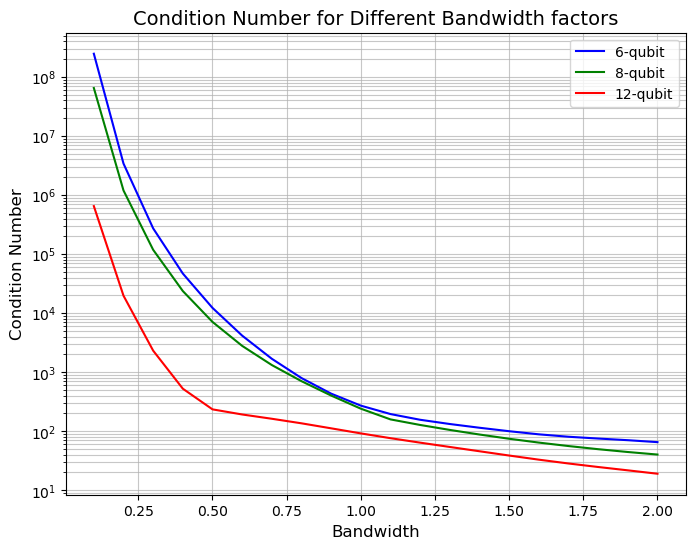

In [13]:
plt.figure(figsize=(8, 6))
plt.semilogy(bandwidth_grid, cond_6q, 'b', label='6-qubit')
plt.semilogy(bandwidth_grid, cond_8q, 'g', label='8-qubit')
plt.semilogy(bandwidth_grid, cond_12q, 'r', label='12-qubit')
plt.title('Condition Number for Different Bandwidth factors', fontsize=14)
plt.xlabel('Bandwidth', fontsize=12)
plt.ylabel('Condition Number', fontsize=12)
plt.grid(True, which="both", linestyle='-', alpha=0.7)
plt.legend()
plt.show()